


Experimentos con Datos con Desgaste

Estudiantes: Matías Carvajal y Daryl Clerc
Profesores: Pablo Estévez, Jorge Vergara
EL7037 - Primavera 2025


Librerías y Funciones Iniciales

In [15]:
import pandas as pd
import numpy as np
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

In [ ]:
# Configuraciones
FEATURES_CANDIDATAS = None    
RANDOM_STATE = 42
TEST_SIZE    = 0.2


### Data

In [4]:
# --- Nusselt number ---
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_n_train_des.txt'
df_n_train = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_n_val_des.txt'
df_n_val = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_n_test_des.txt'
df_n_test = pd.read_csv(file_path, sep=',')

# --- Drag coefficient ---
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_train_des.txt'
df_cdrag_train = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_val_des.txt'
df_cdrag_val = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_test_des.txt'
df_cdrag_test = pd.read_csv(file_path, sep=',')

# --- Friction factor ---
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_train_des.txt'
df_ff_train = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_val_des.txt'
df_ff_val = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_test_des.txt'
df_ff_test = pd.read_csv(file_path, sep=',')

# Vista rápida para validar
print("Nusselt train:", df_n_train.shape, df_n_train.columns.tolist())
print("Drag train:", df_cdrag_train.shape, df_cdrag_train.columns.tolist())
print("Friction train:", df_ff_train.shape, df_ff_train.columns.tolist())


Nusselt train: (13477, 5) ['S', 'Re', 'Pr', 'SoH', 'nusselt']
Drag train: (13432, 4) ['S', 'Re', 'SoH', 'cdrag']
Friction train: (13391, 4) ['S', 'Re', 'SoH', 'frictionFactor']


### Nusselt


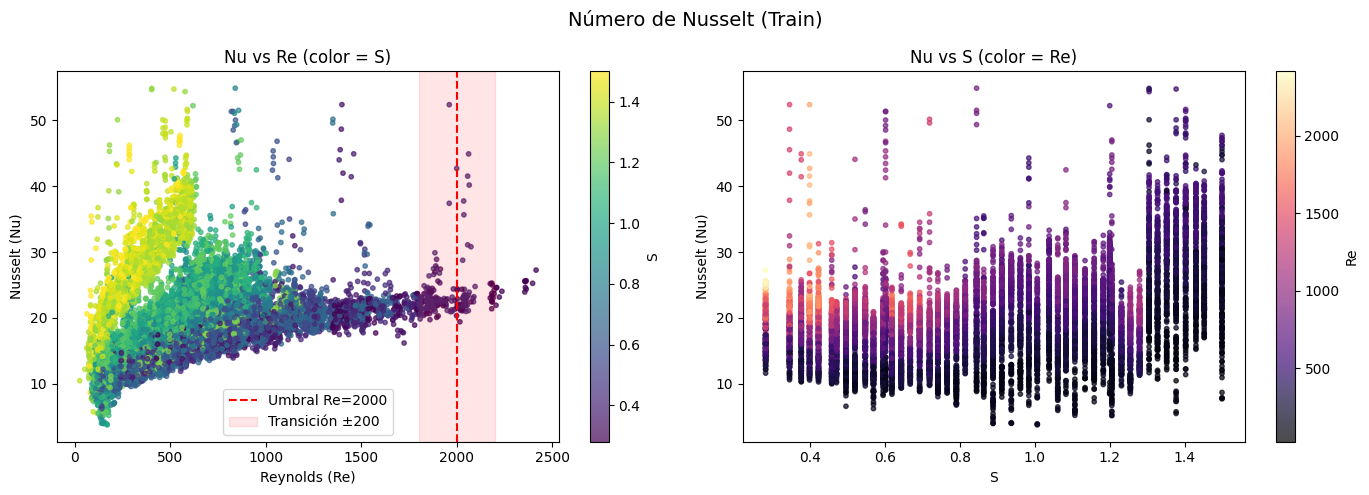

In [49]:
import matplotlib.pyplot as plt

x_train = df_n_train 
y_train = df_n_train["nusselt"]

UMBRAL = 2000
BANDA  = 200   # ancho de transición

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Nu vs Re, coloreado por S ---
sc1 = ax[0].scatter(x_train["Re"], y_train, c=x_train["S"],
                    cmap="viridis", s=10, alpha=0.7)
ax[0].axvline(UMBRAL, color="red", linestyle="--", label=f"Umbral Re={UMBRAL}")
ax[0].axvspan(UMBRAL-BANDA, UMBRAL+BANDA, color="red", alpha=0.1, label=f"Transición ±{BANDA}")
ax[0].set_xlabel("Reynolds (Re)")
ax[0].set_ylabel("Nusselt (Nu)")
ax[0].set_title("Nu vs Re (color = S)")
fig.colorbar(sc1, ax=ax[0], label="S")
ax[0].legend()

# --- Plot 2: Nu vs S, coloreado por Re ---
sc2 = ax[1].scatter(x_train["S"], y_train, c=x_train["Re"],
                    cmap="magma", s=10, alpha=0.7)
ax[1].set_xlabel("S")
ax[1].set_ylabel("Nusselt (Nu)")
ax[1].set_title("Nu vs S (color = Re)")
fig.colorbar(sc2, ax=ax[1], label="Re")

fig.suptitle("Número de Nusselt (Train)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Etiquetar en todo el conjunto (train+val+test juntos)
df_n_all = pd.concat([df_n_train, df_n_val, df_n_test], ignore_index=True)

df_n_all["regimen"] = np.where(df_n_all["Re"] < 2000, "laminar", "turbulento")
df_n_all["en_transicion"] = df_n_all["Re"].between(2000-200, 2000+200)

# Conteos totales
print("Total datos:", len(df_n_all))
print("Laminar:", (df_n_all["regimen"]=="laminar").sum())
print("Turbulento:", (df_n_all["regimen"]=="turbulento").sum())
print("En transición:", df_n_all["en_transicion"].sum())

# También puedes ver la intersección
print("\nLaminar (fuera transición):",
      ((df_n_all["regimen"]=="laminar") & (~df_n_all["en_transicion"])).sum())
print("Turbulento (fuera transición):",
      ((df_n_all["regimen"]=="turbulento") & (~df_n_all["en_transicion"])).sum())


Total datos: 44941
Laminar: 44748
Turbulento: 193
En transición: 493

Laminar (fuera transición): 44396
Turbulento (fuera transición): 52


In [9]:
# --- parámetros simples ---
FEATURES = ["S","Re","Pr","SoH"]
TARGET   = "nusselt"
UMBRAL   = 2000
BANDA    = 200   

In [10]:
# 1) juntar y etiquetar
df = pd.concat([df_n_train, df_n_val], ignore_index=True)  # train+val para entrenar
df["regimen"] = np.where(df["Re"] < UMBRAL, "laminar", "turbulento")
df["en_transicion"] = df["Re"].between(UMBRAL-BANDA, UMBRAL+BANDA)


In [11]:
# 2) hacer subsets
df_mid = df.copy()                              # global (incluye todo)
df_lam = df[(df["regimen"]=="laminar") & (~df["en_transicion"])].copy()
df_tur = df[(df["regimen"]=="turbulento") & (~df["en_transicion"])].copy()

In [12]:
def XY(d): return d[FEATURES].to_numpy(), d[TARGET].to_numpy()


In [13]:
# 3) misma config PySR (Lucas)
def new_model():
    return PySRRegressor(
        niterations=200,
        binary_operators=["+","-","*","/","^"],
        unary_operators=[],
        population_size=50,
        populations=4,
        tournament_selection_n=3,
        verbosity=1,
        maxsize=20,
        parsimony=1e-2,
        constraints={'^':(-1,1)},
        complexity_of_variables=2,
        random_state=0,
        progress=True
    )

In [16]:
# 3a) entrenar global
X_mid, y_mid = XY(df_mid)
mid = new_model(); t0=time.time(); mid.fit(X_mid, y_mid); print("global:", time.time()-t0,"s")

/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
Compiling Julia backend...
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will r


Expressions evaluated per second: 0.000e+00
Progress: 0 / 800 total iterations (0.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.730e+03
Progress: 8 / 800 total iterations (1.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.316e+01  0.000e+00  y = 19.552
4           4.194e+01  9.579e-03  y 

[ Info: Final population:
[ Info: Results saved to:


global: 811.8587477207184 s
  - outputs/20250921_132233_Egwr0m/hall_of_fame.csv


In [ ]:
# 3b) entrenar laminar 
lam = None
if len(df_lam) > 0:
    X_lam, y_lam = XY(df_lam)
    lam = new_model(); t0=time.time(); lam.fit(X_lam, y_lam); print("laminar:", time.time()-t0,"s")
else:
    print("[aviso] subset laminar vacío; usaré global como fallback.")


/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 1.700e+03
Progress: 1 / 800 total iterations (0.125%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
3           4.148e+02  0.000e+00  y = 0.11596 + 0.11596
4           4.322e+01  2.262e+00  y = x₃ + 18.849
6           3.798e+01  6.456e-02  y = (x₀ - -1.5638) / 0.11596
8           3.477e+01  4.413e-02  y = ((x₀ - -1.291) / 0.11691) + 0.7541
10          3.477e+01  5.773e-05  y = ((x₀ - -1.5638) / 0.11596) + (-1.1907 - 0.60133)
11          3.468e+01  2.579e-03  y = (((x₀ - -1.5638) / 0.11596) + x₃) / 1.1331
13          3.423e+01  6.480e-03  y = ((x₀ - -1.5638) / 0.11596) + (-1.0119 / (x₃ / 1.3606))
18          3.373e+01  2.956e-03  y = ((x₀ - -1.5638) / (0.11596 + ((1.1243 * (x₀ / x₁)) ^ 1...
                                      .1505))) - 0.75478
───────────

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 1.100e+04
Progress: 788 / 800 total iterations (98.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.343e+01  0.000e+00  y = 19.504
4           4.156e+01  1.464e-02  y = x₀ + 18.598
6           3.171e+01  1.354e-01  y = (x₀ ^ 6.5061) + 17.243
9           2.139e+01  1.312e-01  y = (x₁ ^ 0.4153) * (x₀ + 0.57367)
11          1.994e+01  3.521e-02  y = (x₁ ^ 0.36625) * ((0.82732 + x₀) ^ 1.2908)
12          1.834e+01  8.346e-02  y = ((x₀ * x₀) - -2.0678) * (x₁ ^ 0.30547)
13          1.637e+01  1.136e-01  y = ((x₁ ^ 0.27004) * ((x₀ ^ 3.2012) + 3.0814)) + -2.5236
15          1.636e+01  2.986e-04  y = (((x₁ ^ 0.27004) * ((x₀ ^ 3.2012) + 3.0814)) + -2.5236...
                                      ) + 0.090186
16          1.560e+01  4.766e-02  y = ((x₁

In [ ]:
# 3c) entrenar turbulento 
tur = None
if len(df_tur) > 0:
    X_tur, y_tur = XY(df_tur)
    tur = new_model(); t0=time.time(); tur.fit(X_tur, y_tur); print("turbulento:", time.time()-t0,"s")
else:
    print("[aviso] subset turbulento vacío; usaré global como fallback.")

/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.650e+05
Progress: 418 / 800 total iterations (52.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.165e+00  0.000e+00  y = 24.734
4           9.941e-01  5.279e-02  y = x₁ ^ 0.41461
6           9.727e-01  1.088e-02  y = (x₁ * 0.0059871) - -10.871
8           9.727e-01  1.192e-07  y = ((x₁ * 0.0059871) + 15.313) - 4.4419
9           9.717e-01  9.588e-04  y = (x₁ * 0.0059871) + (15.313 * x₂)
11          9.535e-01  9.492e-03  y = ((x₃ + (x₁ * 0.0059871)) - -10.871) - 0.93075
13          9.277e-01  1.367e-02  y = (((1.2781 / x₁) ^ -0.60561) * 0.27276) + (-0.80481 / x...
                                      ₃)
15          9.257e-01  1.114e-03  y = (((1.0445 / x₁) ^ -0.62119) * 0.21758) + ((-0.62597 / ...
                                      x₃

In [19]:
# 4) evaluar en test (piecewise vs global)
def predict_piecewise(d):
    re = d["Re"].to_numpy()
    X  = d[FEATURES].to_numpy()
    yhat = np.empty(len(d))
    mask_l = re < (UMBRAL-BANDA)
    mask_t = re > (UMBRAL+BANDA)
    mask_m = ~(mask_l | mask_t)
    yhat[mask_l] = (lam or mid).predict(X[mask_l])
    yhat[mask_t] = (tur or mid).predict(X[mask_t])
    yhat[mask_m] = mid.predict(X[mask_m])  # zona transición
    return yhat

X_te, y_te = df_n_test[FEATURES].to_numpy(), df_n_test[TARGET].to_numpy()
yhat_mid   = mid.predict(X_te)
yhat_piece = predict_piecewise(df_n_test)

print("TEST global  : MSE=%.4f R2=%.4f"%(mean_squared_error(y_te,yhat_mid),   r2_score(y_te,yhat_mid)))
print("TEST piecewise: MSE=%.4f R2=%.4f"%(mean_squared_error(y_te,yhat_piece), r2_score(y_te,yhat_piece)))


TEST global  : MSE=14.4234 R2=0.6265
TEST piecewise: MSE=19.0554 R2=0.5066


In [28]:
import pandas as pd

# Ruta a tu hall_of_fame (ajusta con la que corresponda)
path_hof = "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_132233_Egwr0m/hall_of_fame.csv"
hof = pd.read_csv(path_hof)

print(hof.head(15))



   Complexity       Loss                                           Equation
0           1  43.163445                                           19.55174
1           4  41.376442                                     x0 + 18.653095
2           6  31.872395                       (x0 ^ 6.476371) - -17.337564
3           9  22.116762                (x0 + 1.0161958) * (x1 ^ 0.3734438)
4          11  16.745886  (x1 ^ 0.35097298) / ((x0 * -0.35302523) + 0.78...
5          13  16.494333  ((x1 ^ 0.3734438) / ((x0 * -0.4709393) + 1.016...
6          14  16.323963  ((x1 ^ 0.3734438) / ((x0 * -0.4709393) + 1.016...
7          16  15.864899  (((x1 ^ 0.31312525) + x3) + -1.6660721) / ((x0...
8          18  15.776433  (((x1 ^ 0.33051717) - (x3 * -1.8209629)) + -2....
9          19  15.741444  ((-1.6660721 + (x3 * x3)) + (x1 ^ 0.31312525))...


In [ ]:
import pandas as pd

# Ruta a tu hall_of_fame (ajusta con la que corresponda)
path_hof = "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_133604_mPlIMU/hall_of_fame.csv"
hof = pd.read_csv(path_hof)

print(hof.head(15))



   Complexity       Loss                                           Equation
0           1  43.429000                                          19.504105
1           4  41.562923                                     x0 + 18.598349
2           6  31.705976                        (x0 ^ 6.506126) + 17.242523
3           7  29.012724                             (x1 ^ 0.49629295) * x0
4           9  21.392553               (x1 ^ 0.41530144) * (x0 + 0.5736722)
5          11  19.937965  (x1 ^ 0.3662485) * ((0.8273239 + x0) ^ 1.2908283)
6          12  18.341377        ((x0 * x0) - -2.067819) * (x1 ^ 0.30546835)
7          13  16.371689  ((x1 ^ 0.2700386) * ((x0 ^ 3.2012324) + 3.0814...
8          15  16.361885  (((x1 ^ 0.2700386) * ((x0 ^ 3.2012324) + 3.081...
9          16  15.600397  ((x1 ^ 0.2642912) * ((x0 ^ 3.2084496) + (x3 - ...


In [30]:
import pandas as pd

# Ruta a tu hall_of_fame (ajusta con la que corresponda)
path_hof = "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_134923_b2m6HF/hall_of_fame.csv"
hof = pd.read_csv(path_hof)

print(hof.head(15))



    Complexity      Loss                                           Equation
0            1  1.164645                                          24.733585
1            4  0.994061                                     x1 ^ 0.4146105
2            6  0.972661                   (x1 * 0.0059871254) - -10.871114
3            8  0.972661        ((x1 * 0.005987064) + 15.313141) - 4.441885
4            9  0.949064              (x1 * 0.00688443) - (-7.8540893 - x3)
5           11  0.949064  (x1 * 0.0068831574) - ((-10.276347 - x3) + 2.4...
6           13  0.927749  (((1.2781217 / x1) ^ -0.6056115) * 0.27276325)...
7           15  0.925685  (((1.044474 / x1) ^ -0.62119305) * 0.21758054)...
8           16  0.917822  0.27276325 * (((1.3251495 / x1) ^ -0.6056115) ...
9           18  0.846239  0.27276325 * ((x2 * (1.1644828 / (x1 ^ -0.6056...
10          20  0.837050  (0.27276325 * (((1.1644828 / (x1 ^ -0.6056115)...


In [33]:
import pandas as pd

# rutas de tus hall_of_fame
paths = {
    "Global": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_132233_Egwr0m/hall_of_fame.csv",
    "Re<2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_133604_mPlIMU/hall_of_fame.csv",  # ojo al nombre correcto
    "Re>2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_134923_b2m6HF/hall_of_fame.csv"
}


resumen = []
for nombre, path in paths.items():
    hof = pd.read_csv(path)
    prom = hof["Loss"].mean()
    std  = hof["Loss"].std()
    best = hof.sort_values("Loss").iloc[0]["Loss"]
    resumen.append({"Caso": nombre, "Loss_promedio": prom, "Loss_std": std, "Mejor_Loss": best})

df_resumen = pd.DataFrame(resumen)
print(df_resumen)


      Caso  Loss_promedio   Loss_std  Mejor_Loss
0   Global      23.547600  11.068184   15.741444
1  Re<2000      25.371649  10.509476   15.600397
2  Re>2000       0.950609   0.086420    0.837050


### Coeficiente de arrastre

In [50]:
# --- Drag coefficient ---
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_train_des.txt'
df_cdrag_train = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_val_des.txt'
df_cdrag_val = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_cdrag_test_des.txt'
df_cdrag_test = pd.read_csv(file_path, sep=',')

print("Drag train:", df_cdrag_train.shape, df_cdrag_train.columns.tolist())

Drag train: (13432, 4) ['S', 'Re', 'SoH', 'cdrag']


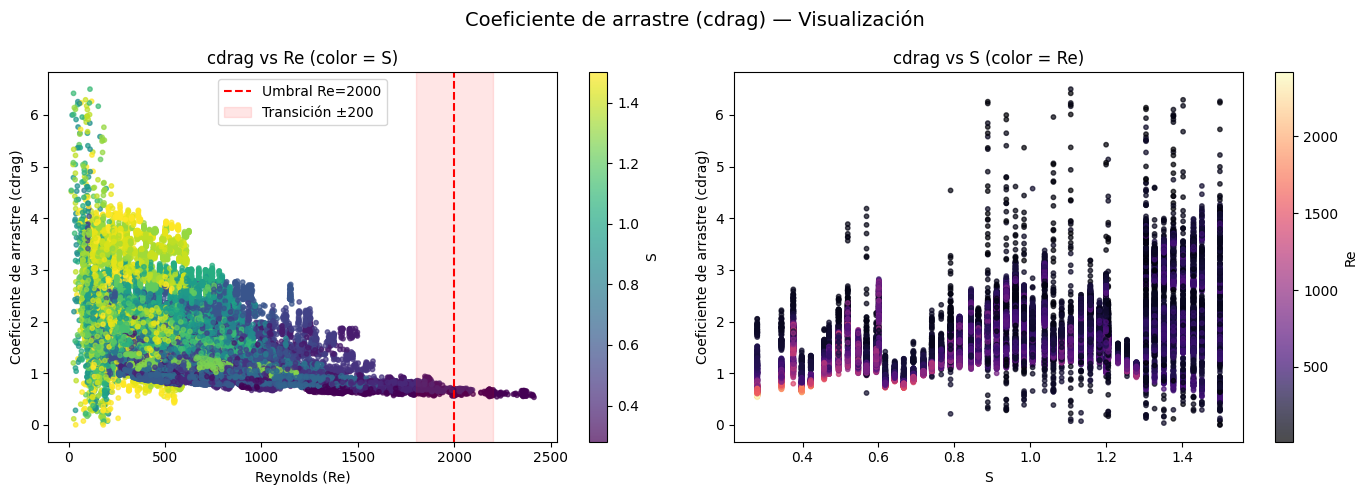

Rango Re: 14.389918982801634 → 2414.258394568012


In [36]:
# Junta los splits para visualizar todo
df_cdrag_all = pd.concat([df_cdrag_train, df_cdrag_val, df_cdrag_test], ignore_index=True)

UMBRAL = 2000
BANDA  = 200

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: cdrag vs Re (color = S) ---
sc1 = ax[0].scatter(df_cdrag_all["Re"], df_cdrag_all["cdrag"],
                    c=df_cdrag_all["S"], cmap="viridis", s=10, alpha=0.7)
ax[0].axvline(UMBRAL, color="red", linestyle="--", label=f"Umbral Re={UMBRAL}")
ax[0].axvspan(UMBRAL-BANDA, UMBRAL+BANDA, color="red", alpha=0.1, label=f"Transición ±{BANDA}")
ax[0].set_xlabel("Reynolds (Re)")
ax[0].set_ylabel("Coeficiente de arrastre (cdrag)")
ax[0].set_title("cdrag vs Re (color = S)")
ax[0].legend()
cb1 = fig.colorbar(sc1, ax=ax[0]); cb1.set_label("S")

# --- Panel 2: cdrag vs S (color = Re) ---
sc2 = ax[1].scatter(df_cdrag_all["S"], df_cdrag_all["cdrag"],
                    c=df_cdrag_all["Re"], cmap="magma", s=10, alpha=0.7)
ax[1].set_xlabel("S")
ax[1].set_ylabel("Coeficiente de arrastre (cdrag)")
ax[1].set_title("cdrag vs S (color = Re)")
cb2 = fig.colorbar(sc2, ax=ax[1]); cb2.set_label("Re")

fig.suptitle("Coeficiente de arrastre (cdrag) — Visualización", fontsize=14)
plt.tight_layout()
plt.show()

print("Rango Re:", df_cdrag_all["Re"].min(), "→", df_cdrag_all["Re"].max())


In [ ]:
# Etiquetar en todo el conjunto 
df_cdrag_all = pd.concat([df_cdrag_train, df_cdrag_val, df_cdrag_test], ignore_index=True)

df_cdrag_all["regimen"] = np.where(df_cdrag_all["Re"] < 2000, "laminar", "turbulento")
df_cdrag_all["en_transicion"] = df_cdrag_all["Re"].between(2000-200, 2000+200)

# Conteos totales
print("Total datos:", len(df_cdrag_all))
print("Laminar:", (df_cdrag_all["regimen"]=="laminar").sum())
print("Turbulento:", (df_cdrag_all["regimen"]=="turbulento").sum())
print("En transición:", df_cdrag_all["en_transicion"].sum())

# También puedes ver la intersección
print("\nLaminar (fuera transición):",
      ((df_cdrag_all["regimen"]=="laminar") & (~df_cdrag_all["en_transicion"])).sum())
print("Turbulento (fuera transición):",
      ((df_cdrag_all["regimen"]=="turbulento") & (~df_cdrag_all["en_transicion"])).sum())


Total datos: 44712
Laminar: 44519
Turbulento: 193
En transición: 493

Laminar (fuera transición): 44167
Turbulento (fuera transición): 52


In [40]:
# --- parámetros simples ---
FEATURES = ["S", "Re", "SoH"]
TARGET   = "cdrag"
UMBRAL   = 2000
BANDA    = 200


In [41]:
# 1) juntar y etiquetar
df = pd.concat([df_cdrag_train, df_cdrag_val], ignore_index=True)  # train+val para entrenar
df["regimen"] = np.where(df["Re"] < UMBRAL, "laminar", "turbulento")
df["en_transicion"] = df["Re"].between(UMBRAL-BANDA, UMBRAL+BANDA)


In [42]:
# 2) hacer subsets
df_mid = df.copy()  # global (incluye todo)
df_lam = df[(df["regimen"]=="laminar") & (~df["en_transicion"])].copy()
df_tur = df[(df["regimen"]=="turbulento") & (~df["en_transicion"])].copy()

print("Total:", len(df), "| Laminar puro:", len(df_lam), "| Turbulento puro:", len(df_tur))


Total: 29073 | Laminar puro: 28688 | Turbulento puro: 27


In [43]:
def XY(d): 
    return d[FEATURES].to_numpy(), d[TARGET].to_numpy()


In [44]:
# 3) misma config PySR (Lucas)
def new_model():
    return PySRRegressor(
        niterations=200,
        binary_operators=["+","-","*","/","^"],
        unary_operators=[],
        population_size=50,
        populations=4,
        tournament_selection_n=3,
        verbosity=1,
        maxsize=20,
        parsimony=1e-2,
        constraints={'^':(-1,1)},
        complexity_of_variables=2,
        random_state=0,
        progress=True
    )


In [45]:
# 3a) entrenar global
X_mid, y_mid = XY(df_mid)
mid = new_model()
t0 = time.time()
mid.fit(X_mid, y_mid)
print("global:", time.time()-t0, "s")


/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 5.050e+03
Progress: 5 / 800 total iterations (0.625%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.234e-01  0.000e+00  y = 1.6866
4           3.898e-01  9.825e-02  y = x₀ - -0.78951
8           3.893e-01  3.177e-04  y = ((x₀ - -0.69533) * 1.0347) / 0.98409
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 5.800e+03
Progress: 10 / 800 total iterations (1.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


global: 693.8318212032318 s
  - outputs/20250921_181514_m6HFIv/hall_of_fame.csv


In [46]:
# 3b) entrenar laminar (si hay datos)
lam = None
if len(df_lam) > 0:
    X_lam, y_lam = XY(df_lam)
    lam = new_model()
    t0 = time.time()
    lam.fit(X_lam, y_lam)
    print("laminar:", time.time()-t0, "s")
else:
    print("[aviso] subset laminar vacío; usaré global como fallback.")


/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 1.920e+03
Progress: 5 / 800 total iterations (0.625%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.173e-01  0.000e+00  y = 1.6997
4           3.922e-01  9.229e-02  y = x₀ - -0.79553
7           3.863e-01  5.058e-03  y = x₀ + (x₁ ^ -0.031619)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.500e+03
Progress: 8 / 800 total iterations (1.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.173e-01  0.000e+00  y = 1.6997
4           3.922e-01  9.229e-02  y = x₀ - -0.79553
6           3.917e-01  6.119e-04  y = (x₀ ^ 1.0761) - -0.79712
7           3.845e-01  1.876e-02  y = (x₁ ^ -0.040235) + x₀
9           3.600e-01  3.283e-02  y = (x₁ * -0.00050678) + (x₀ - -1.0908)
11          3.479e-01  1.719e-02  y = (x₁ ^ -0.19244) * ((x₀ + 1.216) / 0.38611)
13          3.478e-01  4.435e-05  y = (x₁ ^ -0.19244) * ((x₀ + 1.216) / (0.38611 ^ 0.99696))
15          3.478e-01  6.855e-06  y = (((x₁ - 1.6971) * 1.1511) ^ -0.19221) * ((x₀ + 1.2434)...
                                       / 0.38267)
17          3.478e-01  3.648e-05  y = ((((x₁ * 0.15649) / 1.0609) + -0.50078) ^ -0.18765) * ...
                                      ((x₀ + 1.21) / 0.57038)
19          3.478e-01  6.557e-06  y = (((((-1.9951 + x₁) * 0.15649) / 1.0609) + -0.50

In [47]:
# 3c) entrenar turbulento (si hay datos)
tur = None
if len(df_tur) > 0:
    X_tur, y_tur = XY(df_tur)
    tur = new_model()
    t0 = time.time()
    tur.fit(X_tur, y_tur)
    print("turbulento:", time.time()-t0, "s")
else:
    print("[aviso] subset turbulento vacío; usaré global como fallback.")


/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.970e+05
Progress: 223 / 800 total iterations (27.875%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.314e-03  0.000e+00  y = 0.60119
4           1.314e-03  5.960e-08  y = 0.88182 - x₀
6           1.258e-03  2.195e-02  y = (0.055187 * x₂) + 0.55187
8           1.257e-03  4.619e-04  y = ((x₂ ^ 0.22434) * 0.16703) - -0.43704
9           1.253e-03  3.141e-03  y = (x₁ ^ -0.074748) + (x₂ * 0.045658)
11          1.221e-03  1.291e-02  y = (x₂ + ((x₂ ^ -0.52019) + -0.51793)) * 0.40889
16          1.219e-03  2.634e-04  y = ((x₂ * 1.2725) + (x₂ ^ -0.61381)) * ((x₀ ^ -5.1671) * ...
                                      0.00037454)
18          1.219e-03  2.444e-05  y = (((x₂ + 0.0008647) * 1.2725) + (x₂ ^ -0.61381)) * ((x₀...
                            

[ Info: Final population:
[ Info: Results saved to:


turbulento: 16.83162021636963 s
  - outputs/20250921_184624_b2m6HF/hall_of_fame.csv


In [48]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

UMBRAL = 2000
BANDA  = 200

def predict_piecewise(d):
    re = d["Re"].to_numpy()
    X  = d[FEATURES].to_numpy()
    yhat = np.empty(len(d))
    mask_l = re < (UMBRAL - BANDA)
    mask_t = re > (UMBRAL + BANDA)
    mask_m = ~(mask_l | mask_t)
    # fallback al global si lam/tur es None
    yhat[mask_l] = (lam or mid).predict(X[mask_l])
    yhat[mask_t] = (tur or mid).predict(X[mask_t])
    yhat[mask_m] = mid.predict(X[mask_m])
    return yhat

X_te = df_cdrag_test[FEATURES].to_numpy()
y_te = df_cdrag_test[TARGET].to_numpy()

yhat_mid   = mid.predict(X_te)
yhat_piece = predict_piecewise(df_cdrag_test)

print("TEST Global   : MSE=%.4f  R2=%.4f" % (mean_squared_error(y_te, yhat_mid),   r2_score(y_te, yhat_mid)))
print("TEST Piecewise: MSE=%.4f  R2=%.4f" % (mean_squared_error(y_te, yhat_piece), r2_score(y_te, yhat_piece)))


TEST Global   : MSE=0.3233  R2=0.2726
TEST Piecewise: MSE=0.3232  R2=0.2728


In [ ]:
# rutas de hall_of_fame para ff
paths = {
    "Global": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_181514_m6HFIv/hall_of_fame.csv",
    "Re<2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_182802_KojOg7/hall_of_fame.csv",
    "Re>2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_184624_b2m6HF/hall_of_fame.csv"
}

resumen = []
for nombre, path in paths.items():
    hof = pd.read_csv(path)
    prom = hof["Loss"].mean()
    std  = hof["Loss"].std()
    best = hof.sort_values("Loss").iloc[0]["Loss"]
    resumen.append({
        "Caso": nombre,
        "Loss_promedio": prom,
        "Loss_std": std,
        "Mejor_Loss": best
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen)


      Caso  Loss_promedio  Loss_std  Mejor_Loss
0   Global       0.374222  0.052879    0.343195
1  Re<2000       0.375693  0.050584    0.347699
2  Re>2000       0.001267  0.000041    0.001217


### Friction Factor

In [52]:
# --- Friction factor ---
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_train_des.txt'
df_ff_train = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_val_des.txt'
df_ff_val = pd.read_csv(file_path, sep=',')
file_path = '/Users/darylclerc/Desktop/Computacion Evolutiva/data/df_ff_test_des.txt'
df_ff_test = pd.read_csv(file_path, sep=',')

print("FF train:", df_ff_train.shape, df_ff_train.columns.tolist())


FF train: (13391, 4) ['S', 'Re', 'SoH', 'frictionFactor']


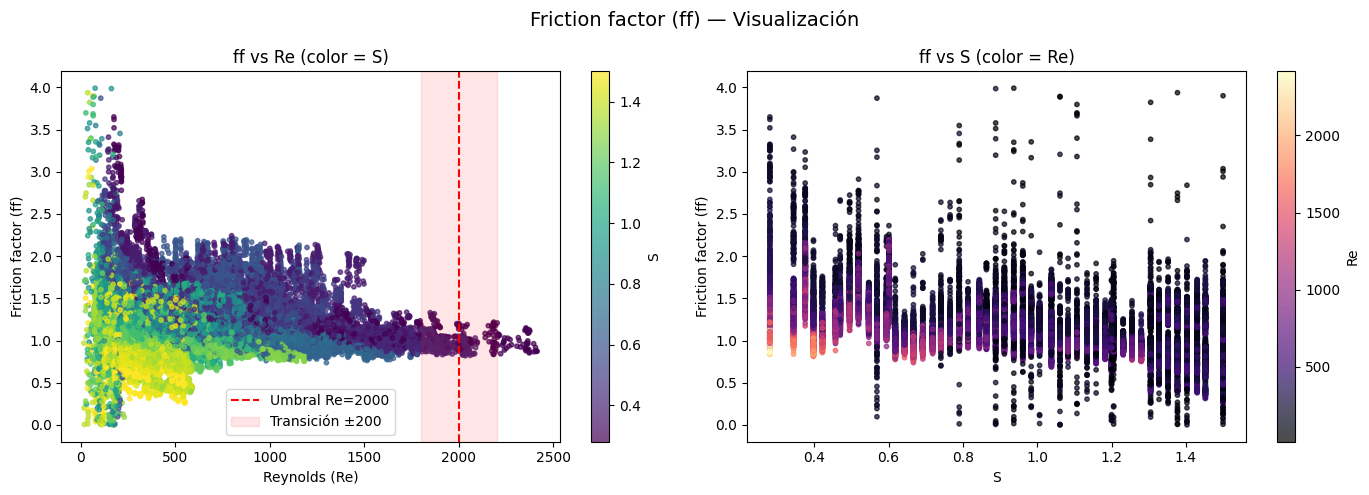

Rango Re: 15.902603659079924 → 2414.258394568012


In [53]:
df_ff_all = pd.concat([df_ff_train, df_ff_val, df_ff_test], ignore_index=True)

UMBRAL = 2000
BANDA  = 200

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: ff vs Re (color = S) ---
sc1 = ax[0].scatter(df_ff_all["Re"], df_ff_all["frictionFactor"],
                    c=df_ff_all["S"], cmap="viridis", s=10, alpha=0.7)
ax[0].axvline(UMBRAL, color="red", linestyle="--", label=f"Umbral Re={UMBRAL}")
ax[0].axvspan(UMBRAL-BANDA, UMBRAL+BANDA, color="red", alpha=0.1, label=f"Transición ±{BANDA}")
ax[0].set_xlabel("Reynolds (Re)")
ax[0].set_ylabel("Friction factor (ff)")
ax[0].set_title("ff vs Re (color = S)")
ax[0].legend()
cb1 = fig.colorbar(sc1, ax=ax[0]); cb1.set_label("S")

# --- Panel 2: ff vs S (color = Re) ---
sc2 = ax[1].scatter(df_ff_all["S"], df_ff_all["frictionFactor"],
                    c=df_ff_all["Re"], cmap="magma", s=10, alpha=0.7)
ax[1].set_xlabel("S")
ax[1].set_ylabel("Friction factor (ff)")
ax[1].set_title("ff vs S (color = Re)")
cb2 = fig.colorbar(sc2, ax=ax[1]); cb2.set_label("Re")

fig.suptitle("Friction factor (ff) — Visualización", fontsize=14)
plt.tight_layout()
plt.show()

print("Rango Re:", df_ff_all["Re"].min(), "→", df_ff_all["Re"].max())


In [54]:
# --- parámetros simples (ff) ---
FEATURES = ["S", "Re", "SoH"]       
TARGET   = "frictionFactor"
UMBRAL   = 2000
BANDA    = 200


In [55]:
df = pd.concat([df_ff_train, df_ff_val], ignore_index=True)
df["regimen"] = np.where(df["Re"] < UMBRAL, "laminar", "turbulento")
df["en_transicion"] = df["Re"].between(UMBRAL - BANDA, UMBRAL + BANDA)


In [56]:
df_mid = df.copy()  # global (incluye todo)
df_lam = df[(df["regimen"]=="laminar") & (~df["en_transicion"])].copy()
df_tur = df[(df["regimen"]=="turbulento") & (~df["en_transicion"])].copy()

print("Total:", len(df), "| Laminar puro:", len(df_lam), "| Turbulento puro:", len(df_tur))


Total: 29018 | Laminar puro: 28633 | Turbulento puro: 27


In [57]:
def XY(d):
    return d[FEATURES].to_numpy(), d[TARGET].to_numpy()


In [58]:
def new_model():
    return PySRRegressor(
        niterations=200,
        binary_operators=["+","-","*","/","^"],
        unary_operators=[],
        population_size=50,
        populations=4,
        tournament_selection_n=3,
        verbosity=1,
        maxsize=20,
        parsimony=1e-2,
        constraints={'^':(-1,1)},
        complexity_of_variables=2,
        random_state=0,
        progress=True
    )


In [59]:
# Global
X_mid, y_mid = XY(df_mid)
mid = new_model(); t0=time.time(); mid.fit(X_mid, y_mid); print("global:", time.time()-t0, "s")

/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 3.260e+03
Progress: 2 / 800 total iterations (0.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.134e-01  0.000e+00  y = 1.2018
6           1.124e-01  1.766e-03  y = 1.411 * (x₁ ^ -0.031619)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.660e+03
Progress: 6 / 800 total iterations (0.750%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss

[ Info: Final population:
[ Info: Results saved to:


global: 1568.5715761184692 s
  - outputs/20250921_190711_Kk8jTp/hall_of_fame.csv


In [60]:
# Laminar
lam = None
if len(df_lam) > 0:
    X_lam, y_lam = XY(df_lam)
    lam = new_model(); t0=time.time(); lam.fit(X_lam, y_lam); print("laminar:", time.time()-t0, "s")
else:
    print("[aviso] subset laminar vacío; fallback=global")

/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic 


Expressions evaluated per second: 7.070e+03
Progress: 5 / 800 total iterations (0.625%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.142e-01  0.000e+00  y = 1.2046
6           9.637e-02  3.400e-02  y = (x₀ ^ -0.28713) + 0.14324
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 5.900e+03
Progress: 9 / 800 total iterations (1.125%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Los

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 5.250e+03
Progress: 796 / 800 total iterations (99.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.142e-01  0.000e+00  y = 1.2045
4           1.129e-01  3.877e-03  y = x₀ ^ -0.39416
6           9.626e-02  7.975e-02  y = 2.1531 - (x₀ ^ 0.3496)
9           8.494e-02  4.171e-02  y = ((x₁ ^ -0.21885) / x₀) + 0.86794
11          7.667e-02  5.120e-02  y = (((x₁ ^ -0.47097) * 5.5922) / x₀) + 0.80227
13          7.664e-02  2.027e-04  y = (((x₁ ^ -0.46759) + -0.0016229) * (5.5539 / x₀)) + 0.8...
                                      0848
16          7.659e-02  2.256e-04  y = 0.80848 + (((x₂ * -0.013016) + ((x₁ ^ -0.46759) * 5.59...
                                      22)) / x₀)
18          7.658e-02  9.328e-06  y = (((x₁ ^ -0.4701) * (5.595 / x₀)

In [61]:
# Turbulento
tur = None
if len(df_tur) > 0:
    X_tur, y_tur = XY(df_tur)
    tur = new_model(); t0=time.time(); tur.fit(X_tur, y_tur); print("turbulento:", time.time()-t0, "s")
else:
    print("[aviso] subset turbulento vacío; fallback=global")


/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/darylclerc/opt/anaconda3/envs/el4203/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.940e+05
Progress: 317 / 800 total iterations (39.625%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.196e-03  0.000e+00  y = 0.98164
4           7.831e-03  1.520e-02  y = x₂ ^ 0.11816
6           7.715e-03  7.437e-03  y = (x₂ * 0.14021) + 0.84993
9           7.686e-03  1.265e-03  y = (x₂ * (x₂ + -1.3568)) - -1.3493
10          7.676e-03  1.263e-03  y = ((-1.32 - (-1.5162 / x₂)) * 6.5243) ^ -0.035461
17          7.660e-03  3.007e-04  y = (((0.25787 + (x₀ ^ -2.3955)) * ((x₂ ^ -2.0811) - 0.879...
                                      57)) - 0.87957) ^ -0.017507
18          7.660e-03  3.219e-06  y = (((x₀ + (x₀ ^ -2.3955)) * ((x₂ ^ -2.0811) - 0.87957)) ...
                                      - 0.87957) ^ -0.017507
19          7.647e-03  1.677e

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.196e-03  0.000e+00  y = 0.98164
4           7.831e-03  1.520e-02  y = x₂ ^ 0.11816
6           7.715e-03  7.437e-03  y = (x₂ * 0.14021) + 0.84993
9           7.686e-03  1.265e-03  y = (x₂ * (x₂ + -1.3568)) - -1.3493
10          7.676e-03  1.263e-03  y = ((-1.32 - (-1.5162 / x₂)) * 6.5243) ^ -0.035461
11          7.675e-03  1.031e-04  y = ((x₂ * (x₂ + -1.3568)) - -1.3493) ^ 0.87174
13          7.675e-03  1.222e-05  y = (((x₂ * (x₂ + -1.3568)) - -1.3493) ^ 0.87174) ^ 1.0054
15          7.660e-03  9.696e-04  y = (((x₀ ^ -2.3955) * ((x₂ ^ -2.0811) - 0.87957)) - 0.889...
                                      75) ^ -0.017507
16          7.631e-03  3.760e-03  y = ((((((x₂ + 0.35551) - 1.2212) + -0.20423) / -0.055852)...
                                       ^ -0.15226) ^ -0.12757) ^ -1.9131
───────────────────────────────────────────────

In [62]:
from sklearn.metrics import mean_squared_error, r2_score

def predict_piecewise(d):
    re = d["Re"].to_numpy()
    X  = d[FEATURES].to_numpy()
    yhat = np.empty(len(d))
    mask_l = re < (UMBRAL - BANDA)
    mask_t = re > (UMBRAL + BANDA)
    mask_m = ~(mask_l | mask_t)
    yhat[mask_l] = (lam or mid).predict(X[mask_l])
    yhat[mask_t] = (tur or mid).predict(X[mask_t])
    yhat[mask_m] = mid.predict(X[mask_m])
    return yhat

X_te, y_te = XY(df_ff_test)
yhat_mid   = mid.predict(X_te)
yhat_piece = predict_piecewise(df_ff_test)

print("TEST Global   : MSE=%.4f  R2=%.4f" % (mean_squared_error(y_te, yhat_mid),   r2_score(y_te, yhat_mid)))
print("TEST Piecewise: MSE=%.4f  R2=%.4f" % (mean_squared_error(y_te, yhat_piece), r2_score(y_te, yhat_piece)))


TEST Global   : MSE=0.0722  R2=0.2695
TEST Piecewise: MSE=0.0822  R2=0.1684


In [ ]:
# rutas de hall_of_fame para friction factor (ff)
paths = {
    "Global": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_190711_Kk8jTp/hall_of_fame.csv",
    "Re<2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_193319_KojOg7/hall_of_fame.csv",
    "Re>2000": "/Users/darylclerc/Desktop/Computacion Evolutiva/outputs/20250921_195216_rl14CH/hall_of_fame.csv"
}

resumen = []
for nombre, path in paths.items():
    hof = pd.read_csv(path)
    prom = hof["Loss"].mean()
    std  = hof["Loss"].std()
    best = hof.sort_values("Loss").iloc[0]["Loss"]
    resumen.append({
        "Caso": nombre,
        "Loss_promedio": prom,
        "Loss_std": std,
        "Mejor_Loss": best
    })

df_resumen = pd.DataFrame(resumen)
print(df_resumen)


      Caso  Loss_promedio  Loss_std  Mejor_Loss
0   Global       0.086389  0.012769    0.076071
1  Re<2000       0.089349  0.016427    0.076584
2  Re>2000       0.007749  0.000177    0.007631
